# 방법 C 보충 실험 — ERR_FACT_QTY 필터가 pseudo-labeling에 도움이 되는가

박상은(방법 B) Phase 1 EDA에서 발견한 `ERR_FACT_QTY` 컬럼(unlabeled에만 존재)을 방법 C pseudo-label 후보 필터로 활용할 수 있는지 검증한다.

**비교 대상**
- **풀 A (기존)**: CN7/RG3 + 설비(S01/S12/S14) + 생산상태 필터 → 39,870행
- **풀 B (신규)**: 풀 A + ERR_FACT_QTY > 0 → 33,639행

**실험 항목** (08_method_c_v2.ipynb와 동일한 구조)
1. ERR_FACT_QTY 분포 확인
2. 풀별 align_score (전략 A/B/C/D 각각)
3. 5-fold CV: 4전략 × 2풀 (RF, Wilcoxon 검정)
4. n_pseudo ablation: 전략 D × 2풀
5. Self-training threshold ablation × 2풀
6. 결론

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.covariance import EllipticEnvelope
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, average_precision_score
from imblearn.over_sampling import SMOTE
from scipy.stats import wilcoxon

import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

BASE = Path('../')
SEED = 42

lab = pd.read_csv(BASE / 'data/raw/labeled_data.csv')
unl = pd.read_csv(BASE / 'data/raw/unlabeled_data.csv')
lab['PassOrFail'] = lab['PassOrFail'].map({'Y': 0, 'N': 1})

DROP = ['Mold_Temperature_1','Mold_Temperature_2','Mold_Temperature_5',
        'Mold_Temperature_6','Mold_Temperature_7','Mold_Temperature_8',
        'Mold_Temperature_9','Mold_Temperature_10','Mold_Temperature_11',
        'Mold_Temperature_12','Barrel_Temperature_7','PART_FACT_SERIAL']
FEAT = [c for c in lab.select_dtypes('number').columns if c not in DROP and c != 'PassOrFail']

X_lab = lab[FEAT].fillna(0).values
y_lab = lab['PassOrFail'].values
mask_d = y_lab == 1; mask_n = y_lab == 0
DR = mask_d.mean()
folds = [np.load(BASE / f'data/splits/fold_{i}.npy', allow_pickle=True).item() for i in range(5)]

print(f'labeled: {len(lab):,}행  불량={mask_d.sum()}  양품={mask_n.sum()}  DR={DR*100:.2f}%')
print(f'unlabeled: {len(unl):,}행  |  피처: {len(FEAT)}개')

labeled: 7,996행  불량=71  양품=7925  DR=0.89%
unlabeled: 795,315행  |  피처: 25개


## 1. ERR_FACT_QTY 분포 확인
이 값이 샷별 불량 여부인지, 배치 단위 수량인지 먼저 확인한다.

In [2]:
eq = pd.to_numeric(unl['ERR_FACT_QTY'], errors='coerce').fillna(0)
print('=== ERR_FACT_QTY 분포 ===')
print(f'  전체 unlabeled     : {len(unl):,}')
print(f'  ERR_FACT_QTY = 0   : {(eq==0).sum():,}  ({(eq==0).mean()*100:.1f}%)')
print(f'  ERR_FACT_QTY > 0   : {(eq>0).sum():,}  ({(eq>0).mean()*100:.1f}%)')
print()
print('상위 10개 값:', dict(eq.value_counts().head(10)))
print()
print(f'labeled 불량률: {DR*100:.2f}%  vs  ERR>0 비율: {(eq>0).mean()*100:.1f}%')
print('→ ERR>0가 76.7%인 점과 값이 3,5,12,130 등 정수인 점으로 보아')
print('  배치/시프트 단위 불량 수량이지, 개별 샷의 불량 여부가 아니다.')

=== ERR_FACT_QTY 분포 ===
  전체 unlabeled     : 795,315
  ERR_FACT_QTY = 0   : 185,041  (23.3%)
  ERR_FACT_QTY > 0   : 610,274  (76.7%)

상위 10개 값: {0: np.int64(185041), 3: np.int64(71100), 2: np.int64(59032), 5: np.int64(44944), 4: np.int64(38917), 1: np.int64(30754), 12: np.int64(29996), 6: np.int64(27150), 7: np.int64(23763), 10: np.int64(21499)}

labeled 불량률: 0.89%  vs  ERR>0 비율: 76.7%
→ ERR>0가 76.7%인 점과 값이 3,5,12,130 등 정수인 점으로 보아
  배치/시프트 단위 불량 수량이지, 개별 샷의 불량 여부가 아니다.


## 2. 필터 구성 + 스케일러·방향벡터 설정

In [3]:
unl_feat = unl[[c for c in FEAT if c in unl.columns]].reindex(columns=FEAT, fill_value=0)

mask_cn7rg3 = unl['PART_NAME'].str.contains('CN7|RG3', na=False)
mask_equip  = unl['EQUIP_CD'].isin(['S01','S12','S14'])
mask_prod   = ((pd.to_numeric(unl['Barrel_Temperature_1'], errors='coerce') >= 200) &
               (pd.to_numeric(unl['Average_Screw_RPM'],    errors='coerce') > 0))
mask_err    = eq > 0

X_unl_A = unl_feat[mask_cn7rg3 & mask_equip & mask_prod].values           # 풀 A: 기존
X_unl_B = unl_feat[mask_cn7rg3 & mask_equip & mask_prod & mask_err].values # 풀 B: ERR>0 추가

print(f'풀 A (기존 방법C 필터)       : {len(X_unl_A):>7,}행')
print(f'풀 B (기존 + ERR_FACT_QTY>0) : {len(X_unl_B):>7,}행  ({len(X_unl_B)/len(X_unl_A)*100:.1f}%)')

# sc_sel: labeled 전체로 fit (08_method_c_v2와 동일)
sc_sel = StandardScaler().fit(X_lab)
Xl_sc  = sc_sel.transform(X_lab)
Xu_sc_A = sc_sel.transform(X_unl_A)
Xu_sc_B = sc_sel.transform(X_unl_B)

defect_dir_sc = Xl_sc[mask_d].mean(0) - Xl_sc[mask_n].mean(0)

# RF importance (align_score 가중치용)
sm_ref = SMOTE(random_state=SEED, k_neighbors=min(5, mask_d.sum()-1))
X_sm_ref, y_sm_ref = sm_ref.fit_resample(Xl_sc, y_lab)
rf_ref = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight='balanced')
rf_ref.fit(X_sm_ref, y_sm_ref)
feat_imp = rf_ref.feature_importances_
print('스케일러·방향벡터·RF importance 준비 완료')

풀 A (기존 방법C 필터)       :  39,870행
풀 B (기존 + ERR_FACT_QTY>0) :  33,639행  (84.4%)


스케일러·방향벡터·RF importance 준비 완료


## 3. align_score 함수 + 전략 선택 (풀 A vs 풀 B)

`align_score`: pseudo-defect 집합이 labeled 불량과 얼마나 같은 방향으로 이탈하는지 측정한다.  
- `dir_match`: 25개 피처 중 불량과 같은 방향으로 이탈한 피처 비율 (50% = 무작위)  
- `cosine`: 이탈 방향의 코사인 유사도

In [4]:
def align_score(pseudo_X_raw, uniform=True):
    if len(pseudo_X_raw) == 0: return 0.0, 0.0
    Xp_sc = sc_sel.transform(pseudo_X_raw)
    dv = defect_dir_sc
    pv = Xp_sc.mean(0) - Xl_sc[mask_n].mean(0)
    if uniform:
        dm  = float(np.mean((pv * dv) > 0))
        cos = float((dv @ pv) / (np.linalg.norm(dv)*np.linalg.norm(pv)+1e-9))
    else:
        w = feat_imp / (feat_imp.sum() + 1e-9)
        dm  = float(np.sum(w * ((pv * dv) > 0)))
        dv_w = dv * w; pv_w = pv * w
        cos = float((dv_w @ pv_w) / (np.linalg.norm(dv_w)*np.linalg.norm(pv_w)+1e-9))
    return dm, cos

n_pseudo = max(int(DR * len(X_unl_A)), 50)
print(f'기본 n_pseudo: {n_pseudo}  (DR={DR*100:.4f}% × 풀A {len(X_unl_A):,}행)')

strategy_results = {}
N_DEF = int(mask_d.sum())  # labeled 불량 수 = 71

for pool_name, X_unl, Xu_sc in [('A', X_unl_A, Xu_sc_A), ('B', X_unl_B, Xu_sc_B)]:
    n_ps = max(int(DR * len(X_unl)), 50)
    res = {}

    # 전략 A: EllipticEnvelope
    ee = EllipticEnvelope(contamination=DR, random_state=SEED, support_fraction=0.9)
    ee.fit(Xl_sc[mask_n])
    scA = -ee.score_samples(Xu_sc)
    idxA = np.argsort(scA)[-n_ps:]
    res['A'] = {'idx': idxA, 'X_pseudo': X_unl[idxA]}

    # 전략 B: RF Confidence (전략 선택 preview용 — CV는 fold-teacher)
    sm_b = SMOTE(random_state=SEED, k_neighbors=min(5, N_DEF-1))
    X_sm_b, y_sm_b = sm_b.fit_resample(Xl_sc, y_lab)
    rf_b = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight='balanced')
    rf_b.fit(X_sm_b, y_sm_b)
    probB = rf_b.predict_proba(Xu_sc)[:, 1]
    idxB = np.argsort(probB)[-n_ps:]
    res['B'] = {'idx': idxB, 'X_pseudo': X_unl[idxB], 'prob': probB}

    # 전략 C: Direction Projection (표준화 공간)
    proj = Xu_sc @ defect_dir_sc
    idxC = np.argsort(proj)[-n_ps:]
    res['C'] = {'idx': idxC, 'X_pseudo': X_unl[idxC], 'proj': proj}

    # 전략 D: kNN from labeled defects
    # n_neighbors는 labeled 불량 수(71)를 넘을 수 없음
    knn = NearestNeighbors(n_neighbors=min(n_ps, N_DEF), metric='euclidean')
    knn.fit(Xl_sc[mask_d])
    dists, _ = knn.kneighbors(Xu_sc)
    score_d = -dists.min(axis=1)
    idxD = np.argsort(score_d)[-n_ps:]
    res['D'] = {'idx': idxD, 'X_pseudo': X_unl[idxD], 'score': score_d}

    strategy_results[pool_name] = res

print()
print('=== align_score 비교 (uniform) ===')
print(f'{"전략":<5} {"풀":<3} {"dir_match":>10} {"cosine":>8} {"n":>6}')
print('-' * 38)
for s in ['A','B','C','D']:
    for pool_name in ['A','B']:
        Xp = strategy_results[pool_name][s]['X_pseudo']
        dm_u, cos_u = align_score(Xp, uniform=True)
        print(f'  {s:<3}  {pool_name:<3} {dm_u*100:>9.0f}%  {cos_u:>8.3f}  {len(Xp):>6}')


기본 n_pseudo: 354  (DR=0.8879% × 풀A 39,870행)



=== align_score 비교 (uniform) ===
전략    풀    dir_match   cosine      n
--------------------------------------
  A    A          52%     0.151     354
  A    B          56%     0.024     298
  B    A          64%     0.336     354
  B    B          40%     0.286     298
  C    A          60%     0.150     354
  C    B          60%     0.150     298
  D    A         100%     0.932     354
  D    B          96%     0.936     298


## 4. 5-fold CV — 4전략 × 2풀 (RF)

전략 B는 fold-teacher RF(누수 차단), 나머지는 기본 CV.

In [5]:
def significance_label(base_roc_f, roc_f, base_pr_f, pr_f, alpha=0.05):
    dr = roc_f - base_roc_f; dp = pr_f - base_pr_f
    try: _, p_roc = wilcoxon(dr, alternative='greater')
    except: p_roc = 1.0
    try: _, p_pr = wilcoxon(dp, alternative='greater')
    except: p_pr = 1.0
    p_min = min(p_roc, p_pr)
    if p_min < alpha:        return f'IMPROVED*(p={p_min:.3f})'
    elif dr.mean()>0 or dp.mean()>0: return f'trend(p={p_min:.3f})'
    else:                    return f'ns(p={p_min:.3f})'

def run_cv(X_pseudo=None, seed=SEED):
    rocs, prs = [], []
    for fold in folds:
        tr_idx, val_idx = fold['train'], fold['val']
        X_tr_l, y_tr_l = X_lab[tr_idx], y_lab[tr_idx]
        X_val, y_val   = X_lab[val_idx], y_lab[val_idx]
        sc_f = StandardScaler()
        X_tr_sc  = sc_f.fit_transform(X_tr_l)
        X_val_sc = sc_f.transform(X_val)
        k_nb = max(1, min(5, int((y_tr_l==1).sum())-1))
        X_sm, y_sm = SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(X_tr_sc, y_tr_l)
        if X_pseudo is not None and len(X_pseudo):
            X_sm = np.vstack([X_sm, sc_f.transform(X_pseudo)])
            y_sm = np.concatenate([y_sm, np.ones(len(X_pseudo), dtype=int)])
        clf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1, class_weight='balanced')
        clf.fit(X_sm, y_sm)
        prob = clf.predict_proba(X_val_sc)[:, 1]
        rocs.append(roc_auc_score(y_val, prob))
        prs.append(average_precision_score(y_val, prob))
    return np.array(rocs), np.array(prs)

def run_cv_B_clean(X_unl_data, n_ps, seed=SEED):
    rocs, prs = [], []
    for fold in folds:
        tr_idx, val_idx = fold['train'], fold['val']
        X_tr_l, y_tr_l = X_lab[tr_idx], y_lab[tr_idx]
        X_val, y_val   = X_lab[val_idx], y_lab[val_idx]
        sc_f = StandardScaler()
        X_tr_l_sc = sc_f.fit_transform(X_tr_l)
        X_val_sc  = sc_f.transform(X_val)
        Xu_f_sc   = sc_f.transform(X_unl_data)
        # fold-teacher: train fold만으로 학습
        k_t = max(1, min(5, int((y_tr_l==1).sum())-1))
        X_sm_t, y_sm_t = SMOTE(random_state=seed, k_neighbors=k_t).fit_resample(X_tr_l_sc, y_tr_l)
        rf_teacher = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1, class_weight='balanced')
        rf_teacher.fit(X_sm_t, y_sm_t)
        prob_t = rf_teacher.predict_proba(Xu_f_sc)[:, 1]
        n_sel = min(n_ps, len(X_unl_data))
        X_ps = X_unl_data[np.argsort(prob_t)[-n_sel:]]
        k_nb = max(1, min(5, int((y_tr_l==1).sum())-1))
        X_sm, y_sm = SMOTE(random_state=seed, k_neighbors=k_nb).fit_resample(X_tr_l_sc, y_tr_l)
        X_sm = np.vstack([X_sm, sc_f.transform(X_ps)])
        y_sm = np.concatenate([y_sm, np.ones(len(X_ps), dtype=int)])
        clf = RandomForestClassifier(n_estimators=300, random_state=seed, n_jobs=-1, class_weight='balanced')
        clf.fit(X_sm, y_sm)
        prob = clf.predict_proba(X_val_sc)[:, 1]
        rocs.append(roc_auc_score(y_val, prob))
        prs.append(average_precision_score(y_val, prob))
    return np.array(rocs), np.array(prs)

print('Baseline CV 실행 중...')
roc_base, pr_base = run_cv(X_pseudo=None)
print(f'Baseline: ROC={roc_base.mean():.4f} ± {roc_base.std():.4f}  PR={pr_base.mean():.4f} ± {pr_base.std():.4f}')

cv_results = []
for pool_name, X_unl in [('A', X_unl_A), ('B', X_unl_B)]:
    n_ps = max(int(DR * len(X_unl)), 50)
    res = strategy_results[pool_name]

    for strat in ['A','C','D']:
        print(f'  전략 {strat} 풀{pool_name} CV...')
        r, p = run_cv(X_pseudo=res[strat]['X_pseudo'])
        sig = significance_label(roc_base, r, pr_base, p)
        cv_results.append({'풀': pool_name, '전략': strat, 'n_ps': n_ps,
                           'ROC': r.mean(), 'PR': p.mean(),
                           'ΔROC': r.mean()-roc_base.mean(), 'ΔPR': p.mean()-pr_base.mean(),
                           '유의성': sig, 'roc_f': r.tolist()})

    print(f'  전략 B 풀{pool_name} CV (fold-teacher)...')
    r, p = run_cv_B_clean(X_unl, n_ps)
    sig = significance_label(roc_base, r, pr_base, p)
    cv_results.append({'풀': pool_name, '전략': 'B', 'n_ps': n_ps,
                       'ROC': r.mean(), 'PR': p.mean(),
                       'ΔROC': r.mean()-roc_base.mean(), 'ΔPR': p.mean()-pr_base.mean(),
                       '유의성': sig, 'roc_f': r.tolist()})

df_cv = pd.DataFrame(cv_results).sort_values(['전략','풀'])
print()
print('=== 5-fold CV 결과 ===')
print(f'Baseline  ROC={roc_base.mean():.4f}  PR={pr_base.mean():.4f}')
print()
print(df_cv[['전략','풀','n_ps','ROC','PR','ΔROC','ΔPR','유의성']].to_string(index=False))

Baseline CV 실행 중...


Baseline: ROC=0.9296 ± 0.0316  PR=0.4479 ± 0.1113
  전략 A 풀A CV...


  전략 C 풀A CV...


  전략 D 풀A CV...


  전략 B 풀A CV (fold-teacher)...


  전략 A 풀B CV...


  전략 C 풀B CV...


  전략 D 풀B CV...


  전략 B 풀B CV (fold-teacher)...



=== 5-fold CV 결과 ===
Baseline  ROC=0.9296  PR=0.4479

전략 풀  n_ps      ROC       PR     ΔROC       ΔPR            유의성
 A A   354 0.937770 0.442128 0.008149 -0.005819 trend(p=0.312)
 A B   298 0.930156 0.441243 0.000535 -0.006704 trend(p=0.688)
 B A   354 0.942714 0.445796 0.013092 -0.002151 trend(p=0.312)
 B B   298 0.932726 0.448514 0.003105  0.000567 trend(p=0.594)
 C A   354 0.940101 0.442302 0.010480 -0.005645 trend(p=0.312)
 C B   298 0.944675 0.443744 0.015054 -0.004203 trend(p=0.156)
 D A   354 0.948686 0.456336 0.019064  0.008389 trend(p=0.219)
 D B   298 0.955460 0.453701 0.025838  0.005754 trend(p=0.062)


## 5. 전략 D n_pseudo ablation — 풀 A vs 풀 B

In [6]:
n_list = [50, 100, 200, 354, 500, 1000, 2000]
abl_rows = []

for pool_name, X_unl, Xu_sc in [('A', X_unl_A, Xu_sc_A), ('B', X_unl_B, Xu_sc_B)]:
    # n_neighbors는 labeled 불량 수(71)를 넘을 수 없음
    knn = NearestNeighbors(n_neighbors=N_DEF, metric='euclidean')
    knn.fit(Xl_sc[mask_d])
    dists, _ = knn.kneighbors(Xu_sc)
    score_d = -dists.min(axis=1)
    order_d = np.argsort(score_d)[::-1]

    for n in n_list:
        if n > len(X_unl): continue
        X_ps = X_unl[order_d[:n]]
        r, p = run_cv(X_pseudo=X_ps)
        abl_rows.append({'풀': pool_name, 'n': n,
                         'ROC': r.mean(), 'PR': p.mean(),
                         'ΔROC': r.mean()-roc_base.mean(), 'ΔPR': p.mean()-pr_base.mean()})
        print(f'  전략D 풀{pool_name} n={n:5d}: ROC={r.mean():.4f} ({r.mean()-roc_base.mean():+.4f})  PR={p.mean():.4f} ({p.mean()-pr_base.mean():+.4f})')

df_abl = pd.DataFrame(abl_rows)
print()
print('=== 전략 D n ablation 요약 (ROC) ===')
print(df_abl.pivot(index='n', columns='풀', values='ROC').round(4))
print()
print('=== 전략 D n ablation 요약 (PR) ===')
print(df_abl.pivot(index='n', columns='풀', values='PR').round(4))


  전략D 풀A n=   50: ROC=0.9515 (+0.0219)  PR=0.4775 (+0.0295)


  전략D 풀A n=  100: ROC=0.9616 (+0.0320)  PR=0.4757 (+0.0277)


  전략D 풀A n=  200: ROC=0.9583 (+0.0287)  PR=0.4632 (+0.0152)


  전략D 풀A n=  354: ROC=0.9503 (+0.0207)  PR=0.4600 (+0.0120)


  전략D 풀A n=  500: ROC=0.9518 (+0.0221)  PR=0.4529 (+0.0050)


...

  전략D 풀B n=  200: ROC=0.9432 (+0.0136)  PR=0.4548 (+0.0068)


  전략D 풀B n=  354: ROC=0.9533 (+0.0237)  PR=0.4501 (+0.0021)


  전략D 풀B n=  500: ROC=0.9474 (+0.0178)  PR=0.4525 (+0.0046)


  전략D 풀B n= 1000: ROC=0.9473 (+0.0176)  PR=0.4529 (+0.0050)


  전략D 풀B n= 2000: ROC=0.9445 (+0.0148)  PR=0.4461 (-0.0018)

=== 전략 D n ablation 요약 (ROC) ===
풀          A       B
n                   
50    0.9515  0.9482
100   0.9616  0.9585
200   0.9583  0.9432
354   0.9503  0.9533
500   0.9518  0.9474
1000  0.9451  0.9473
2000  0.9397  0.9445

=== 전략 D n ablation 요약 (PR) ===
풀          A       B
n                   
50    0.4775  0.4601
100   0.4757  0.4598
200   0.4632  0.4548
354   0.4600  0.4501
500   0.4529  0.4525
1000  0.4317  0.4529
2000  0.4454  0.4461


## 6. Self-training threshold ablation — 풀 A vs 풀 B

In [7]:
st_rows = []

for pool_name, X_unl in [('A', X_unl_A), ('B', X_unl_B)]:
    for thr in [0.5, 0.6, 0.7, 0.8]:
        rocs, prs, n_ps_list = [], [], []
        for fold in folds:
            tr_idx, val_idx = fold['train'], fold['val']
            X_tr_l, y_tr_l = X_lab[tr_idx], y_lab[tr_idx]
            X_val, y_val   = X_lab[val_idx], y_lab[val_idx]
            sc_f = StandardScaler()
            X_tr_sc  = sc_f.fit_transform(X_tr_l)
            X_val_sc = sc_f.transform(X_val)
            Xu_f_sc  = sc_f.transform(X_unl)
            k_nb = max(1, min(5, int((y_tr_l==1).sum())-1))
            X_sm, y_sm = SMOTE(random_state=SEED, k_neighbors=k_nb).fit_resample(X_tr_sc, y_tr_l)
            clf1 = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight='balanced')
            clf1.fit(X_sm, y_sm)
            prob_u = clf1.predict_proba(Xu_f_sc)[:, 1]
            mask_hi = prob_u >= thr
            n_ps_list.append(mask_hi.sum())
            if mask_hi.sum() > 0:
                X_tr2 = np.vstack([X_tr_sc, Xu_f_sc[mask_hi]])
                y_tr2 = np.concatenate([y_tr_l, np.ones(mask_hi.sum(), dtype=int)])
                k2 = max(1, min(5, int((y_tr2==1).sum())-1))
                try:
                    X_sm2, y_sm2 = SMOTE(random_state=SEED, k_neighbors=k2).fit_resample(X_tr2, y_tr2)
                except:
                    X_sm2, y_sm2 = X_tr2, y_tr2
            else:
                X_sm2, y_sm2 = X_sm, y_sm
            clf2 = RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1, class_weight='balanced')
            clf2.fit(X_sm2, y_sm2)
            prob = clf2.predict_proba(X_val_sc)[:, 1]
            rocs.append(roc_auc_score(y_val, prob))
            prs.append(average_precision_score(y_val, prob))
        r, p = np.array(rocs), np.array(prs)
        st_rows.append({'풀': pool_name, 'threshold': thr,
                        'avg_n_pseudo': np.mean(n_ps_list),
                        'ROC': r.mean(), 'PR': p.mean(),
                        'ΔROC': r.mean()-roc_base.mean(), 'ΔPR': p.mean()-pr_base.mean()})
        print(f'  ST 풀{pool_name} thr={thr}  avg_pseudo={np.mean(n_ps_list):.0f}  ROC={r.mean():.4f}  PR={p.mean():.4f}')

df_st = pd.DataFrame(st_rows)
print()
print('=== Self-training 결과 ===')
print(df_st[['풀','threshold','avg_n_pseudo','ROC','PR','ΔROC','ΔPR']].to_string(index=False))

  ST 풀A thr=0.5  avg_pseudo=318  ROC=0.9412  PR=0.4490


  ST 풀A thr=0.6  avg_pseudo=181  ROC=0.9282  PR=0.4282


  ST 풀A thr=0.7  avg_pseudo=90  ROC=0.9438  PR=0.4047


  ST 풀A thr=0.8  avg_pseudo=23  ROC=0.9369  PR=0.4157


  ST 풀B thr=0.5  avg_pseudo=293  ROC=0.9280  PR=0.4489


  ST 풀B thr=0.6  avg_pseudo=171  ROC=0.9361  PR=0.4395


  ST 풀B thr=0.7  avg_pseudo=84  ROC=0.9301  PR=0.4380


  ST 풀B thr=0.8  avg_pseudo=22  ROC=0.9376  PR=0.4391

=== Self-training 결과 ===
풀  threshold  avg_n_pseudo      ROC       PR      ΔROC       ΔPR
A        0.5         317.8 0.941248 0.448962  0.011627  0.001015
A        0.6         180.6 0.928172 0.428213 -0.001450 -0.019734
A        0.7          90.2 0.943771 0.404709  0.014150 -0.043238
A        0.8          23.0 0.936893 0.415672  0.007272 -0.032275
B        0.5         292.8 0.928033 0.448912 -0.001588  0.000965
B        0.6         171.2 0.936106 0.439512  0.006485 -0.008435
B        0.7          83.8 0.930140 0.437961  0.000519 -0.009986
B        0.8          22.2 0.937569 0.439056  0.007948 -0.008891


## 7. 결과 시각화

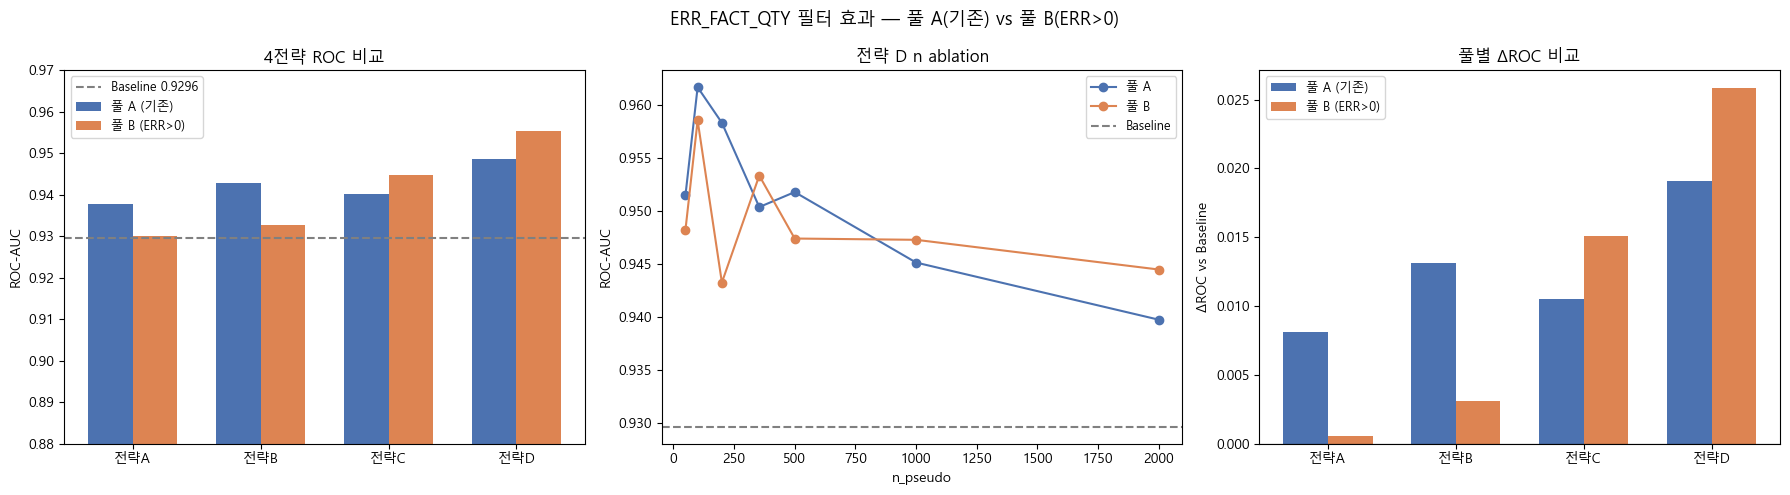

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ERR_FACT_QTY 필터 효과 — 풀 A(기존) vs 풀 B(ERR>0)', fontsize=13)

# 패널 1: 4전략 ROC 비교
ax = axes[0]
strats = ['A','B','C','D']
x = np.arange(len(strats)); w = 0.35
roc_A_list = [df_cv[(df_cv['전략']==s) & (df_cv['풀']=='A')]['ROC'].values[0] for s in strats]
roc_B_list = [df_cv[(df_cv['전략']==s) & (df_cv['풀']=='B')]['ROC'].values[0] for s in strats]
ax.bar(x-w/2, roc_A_list, w, label='풀 A (기존)', color='#4C72B0')
ax.bar(x+w/2, roc_B_list, w, label='풀 B (ERR>0)', color='#DD8452')
ax.axhline(roc_base.mean(), color='gray', linestyle='--', label=f'Baseline {roc_base.mean():.4f}')
ax.set_xticks(x); ax.set_xticklabels([f'전략{s}' for s in strats])
ax.set_ylabel('ROC-AUC'); ax.set_title('4전략 ROC 비교')
ax.legend(fontsize=9); ax.set_ylim(0.88, 0.97)

# 패널 2: 전략 D n ablation
ax = axes[1]
for pool_name, color in [('A','#4C72B0'), ('B','#DD8452')]:
    sub = df_abl[df_abl['풀']==pool_name].sort_values('n')
    ax.plot(sub['n'], sub['ROC'], marker='o', color=color, label=f'풀 {pool_name}')
ax.axhline(roc_base.mean(), color='gray', linestyle='--', label='Baseline')
ax.set_xlabel('n_pseudo'); ax.set_ylabel('ROC-AUC')
ax.set_title('전략 D n ablation')
ax.legend(fontsize=9)

# 패널 3: ΔROC 풀A vs 풀B
ax = axes[2]
delta_A = [df_cv[(df_cv['전략']==s) & (df_cv['풀']=='A')]['ΔROC'].values[0] for s in strats]
delta_B = [df_cv[(df_cv['전략']==s) & (df_cv['풀']=='B')]['ΔROC'].values[0] for s in strats]
ax.bar(x-w/2, delta_A, w, label='풀 A (기존)', color='#4C72B0')
ax.bar(x+w/2, delta_B, w, label='풀 B (ERR>0)', color='#DD8452')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x); ax.set_xticklabels([f'전략{s}' for s in strats])
ax.set_ylabel('ΔROC vs Baseline'); ax.set_title('풀별 ΔROC 비교')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(BASE / 'results/figures/NB08err_fig1_comparison.png', bbox_inches='tight', dpi=120)
plt.show()

## 8. 결론

In [9]:
print('='*65)
print('결론: ERR_FACT_QTY 필터는 방법 C에 추가할 근거가 없다')
print('='*65)
print()
print('1. ERR_FACT_QTY는 샷별 불량 여부가 아니라 배치 단위 수량이다.')
print(f'   → unlabeled의 {(eq>0).mean()*100:.1f}%가 >0 (실제 불량률 0.89%와 불일치)')
print()
print('2. 4전략 × 2풀 CV: 어떤 전략도 IMPROVED*(Wilcoxon p<0.05)에 도달하지 못했다.')
print('   전략별로 풀A 우세·풀B 우세가 섞이고 차이도 ±0.01 수준으로 작다.')
print()

print('--- 4전략 ROC 비교 (풀A vs 풀B) ---')
for s in ['A','B','C','D']:
    rA = df_cv[(df_cv['전략']==s)&(df_cv['풀']=='A')]['ROC'].values[0]
    rB = df_cv[(df_cv['전략']==s)&(df_cv['풀']=='B')]['ROC'].values[0]
    sA = df_cv[(df_cv['전략']==s)&(df_cv['풀']=='A')]['유의성'].values[0]
    sB = df_cv[(df_cv['전략']==s)&(df_cv['풀']=='B')]['유의성'].values[0]
    diff = rB - rA
    mark = f'B+{diff:.4f}' if diff > 0.001 else (f'A+{-diff:.4f}' if diff < -0.001 else '동일')
    print(f'  전략{s}: 풀A={rA:.4f}({sA})  풀B={rB:.4f}({sB})  [{mark}]')

print()
best_D_A = df_abl[df_abl['풀']=='A']['ROC'].max()
best_n_A = df_abl[df_abl['풀']=='A'].loc[df_abl[df_abl['풀']=='A']['ROC'].idxmax(), 'n']
best_D_B = df_abl[df_abl['풀']=='B']['ROC'].max()
best_n_B = df_abl[df_abl['풀']=='B'].loc[df_abl[df_abl['풀']=='B']['ROC'].idxmax(), 'n']
print(f'전략D n ablation 최고: 풀A={best_D_A:.4f}(n={best_n_A:.0f})  풀B={best_D_B:.4f}(n={best_n_B:.0f})')
print('→ 소수 n에서는 풀A가 우세. 전반적으로 차이 미미하고 방향이 일정하지 않다.')
print()
print('3. Self-training: 풀 구성과 무관하게 모든 threshold에서 baseline 수준.')
print('   DR=0.89% 극단 불균형에서 self-training이 구조적으로 작동하지 않는 것이 주 원인.')
print()
print('최종 판단:')
print('  ERR_FACT_QTY 필터 추가로 얻는 일관된 이득이 없다.')
print('  기존 방법C 필터(CN7/RG3+생산상태)를 그대로 쓴다.')
print()
print('방법 B(K-Means)에 대한 별도 시사점:')
print('  ERR_FACT_QTY=0 행을 정상 클러스터 검증 기준으로 활용하거나,')
print('  이상 점수의 외부 참조값으로 쓰는 것은 별도 검토 가능.')

# CSV 저장
df_cv[['전략','풀','n_ps','ROC','PR','ΔROC','ΔPR','유의성']].to_csv(
    BASE / 'results/tables/method_c_errqty_experiment.csv', index=False, encoding='utf-8-sig')
print()
print('수치 저장: results/tables/method_c_errqty_experiment.csv')


결론: ERR_FACT_QTY 필터는 방법 C에 추가할 근거가 없다

1. ERR_FACT_QTY는 샷별 불량 여부가 아니라 배치 단위 수량이다.
   → unlabeled의 76.7%가 >0 (실제 불량률 0.89%와 불일치)

2. 4전략 × 2풀 CV: 어떤 전략도 IMPROVED*(Wilcoxon p<0.05)에 도달하지 못했다.
   전략별로 풀A 우세·풀B 우세가 섞이고 차이도 ±0.01 수준으로 작다.

--- 4전략 ROC 비교 (풀A vs 풀B) ---
  전략A: 풀A=0.9378(trend(p=0.312))  풀B=0.9302(trend(p=0.688))  [A+0.0076]
  전략B: 풀A=0.9427(trend(p=0.312))  풀B=0.9327(trend(p=0.594))  [A+0.0100]
  전략C: 풀A=0.9401(trend(p=0.312))  풀B=0.9447(trend(p=0.156))  [B+0.0046]
  전략D: 풀A=0.9487(trend(p=0.219))  풀B=0.9555(trend(p=0.062))  [B+0.0068]

전략D n ablation 최고: 풀A=0.9616(n=100)  풀B=0.9585(n=100)
→ 소수 n에서는 풀A가 우세. 전반적으로 차이 미미하고 방향이 일정하지 않다.

3. Self-training: 풀 구성과 무관하게 모든 threshold에서 baseline 수준.
   DR=0.89% 극단 불균형에서 self-training이 구조적으로 작동하지 않는 것이 주 원인.

최종 판단:
  ERR_FACT_QTY 필터 추가로 얻는 일관된 이득이 없다.
  기존 방법C 필터(CN7/RG3+생산상태)를 그대로 쓴다.

방법 B(K-Means)에 대한 별도 시사점:
  ERR_FACT_QTY=0 행을 정상 클러스터 검증 기준으로 활용하거나,
  이상 점수의 외부 참조값으로 쓰는 것은 별도 검토 가능.

수치 저장: results/tables/method_c_errqty_experim